# **K-Means**

Algoritmo de **clusterização** (agrupamento) para conjuntos de dados não rotulados, com base na similaridade dos itens do conjunto.

O algoritmo se baseia em iterações sucessivas de cálculo de distâncias entre um grupo de dados em relação a um ponto central (os chamados **centroides**), até chegar em um ponto que a distância seja satisfatória ou o número de iterações chegue ao seu limite.

# **Aplicação do algoritmo**

O algoritmo será executado sobre o [dataset **Iris**](https://www.kaggle.com/datasets/himanshunakrani/iris-dataset), que fornece informações e propriedades sobre 50 amostras de 3 espécies distintas da flor de Íris.

**Informações sobre as features do dataset:**

1.  **sepal_length:** comprimento da sépala em cm
2.  **sepal_width:**  largura da sépala em cm
3.  **petal_length:** comprimento da pétala em cm
4.  **petal_width:**  largura da pétala em cm
5.  **species:** espécies ->
    -- Iris Setosa
    -- Iris Versicolour
    -- Iris Virginica

A motivação será a de agrupar as amostras em suas respectivas espécies com base em suas características físicas, **desconsiderando**, portanto, a coluna que informa a qual espécie a mesma pertence.

**Estrutura da aplicação:**



1.   Carregar os dados
2.   Visualização e Preparação dos dados
3.   Treino do modelo
4.   Validação do modelo com métricas

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 1 - Carregar e vistoriar os dados

In [116]:
# Carregando os dados
df = pd.read_csv('/content/iris.csv')

In [117]:
# Sumário do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [118]:
# Visualização das 5 primeiras linhas
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [119]:
# Descrição estatística da estrutura
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2 - Visualização dos dados

In [120]:
# Modularizando funções de exibição gráfica das variáveis

# Histograma
def histograma(numero_coluna, data):
  sns.histplot(data=data, x=data.columns[numero_coluna])
  plt.title(f'Distribuição da feature {data.columns[numero_coluna]}')
  plt.ylabel('Frequência')
  plt.show()

# Boxplot
def boxplot(numero_coluna, data):
  sns.boxplot(data=data, y=data.columns[numero_coluna])
  plt.show()

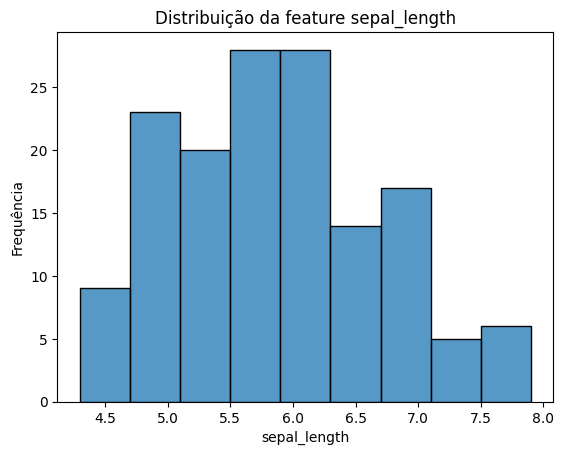

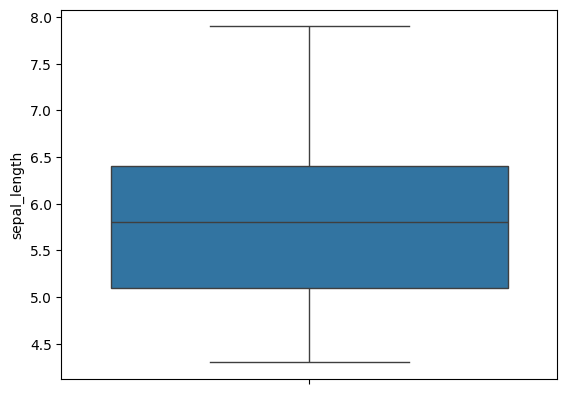

In [121]:
# Feature sepal_length
histograma(0,df)
boxplot(0,df)

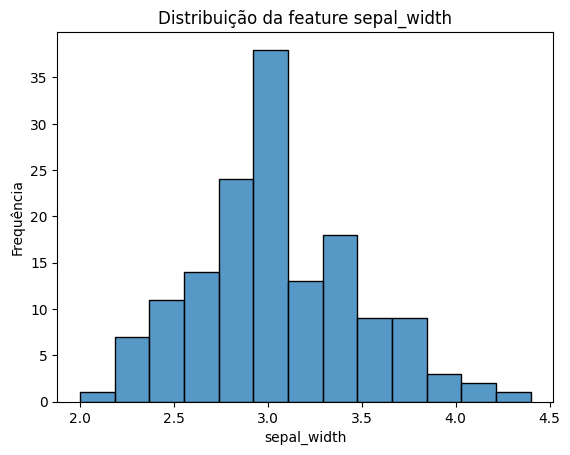

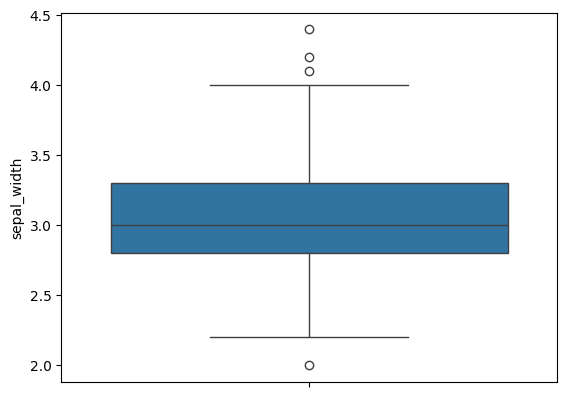

In [122]:
# Feature sepal width
histograma(1,df)
boxplot(1,df)

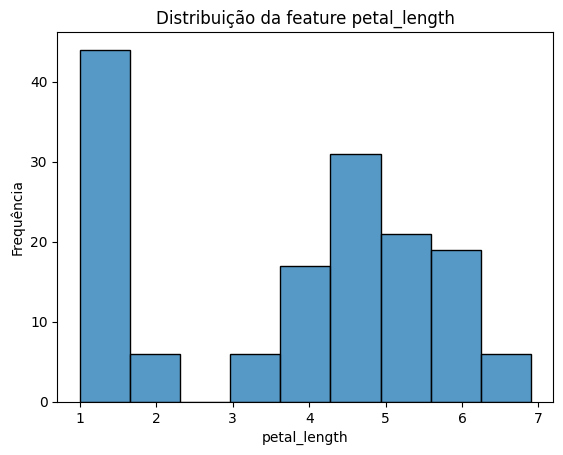

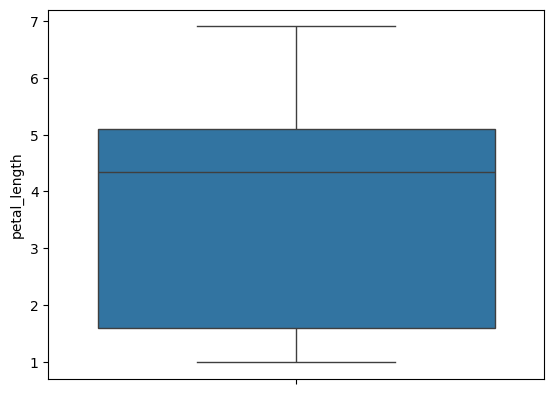

In [123]:
# Feature petal_length
histograma(2, df)
boxplot(2,df)

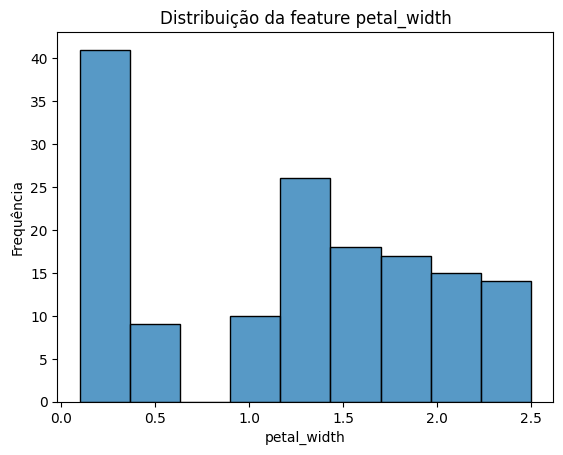

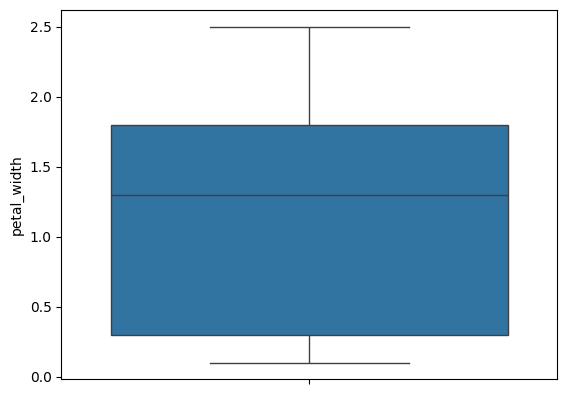

In [124]:
# Feature petal_width
histograma(3,df)
boxplot(3,df)

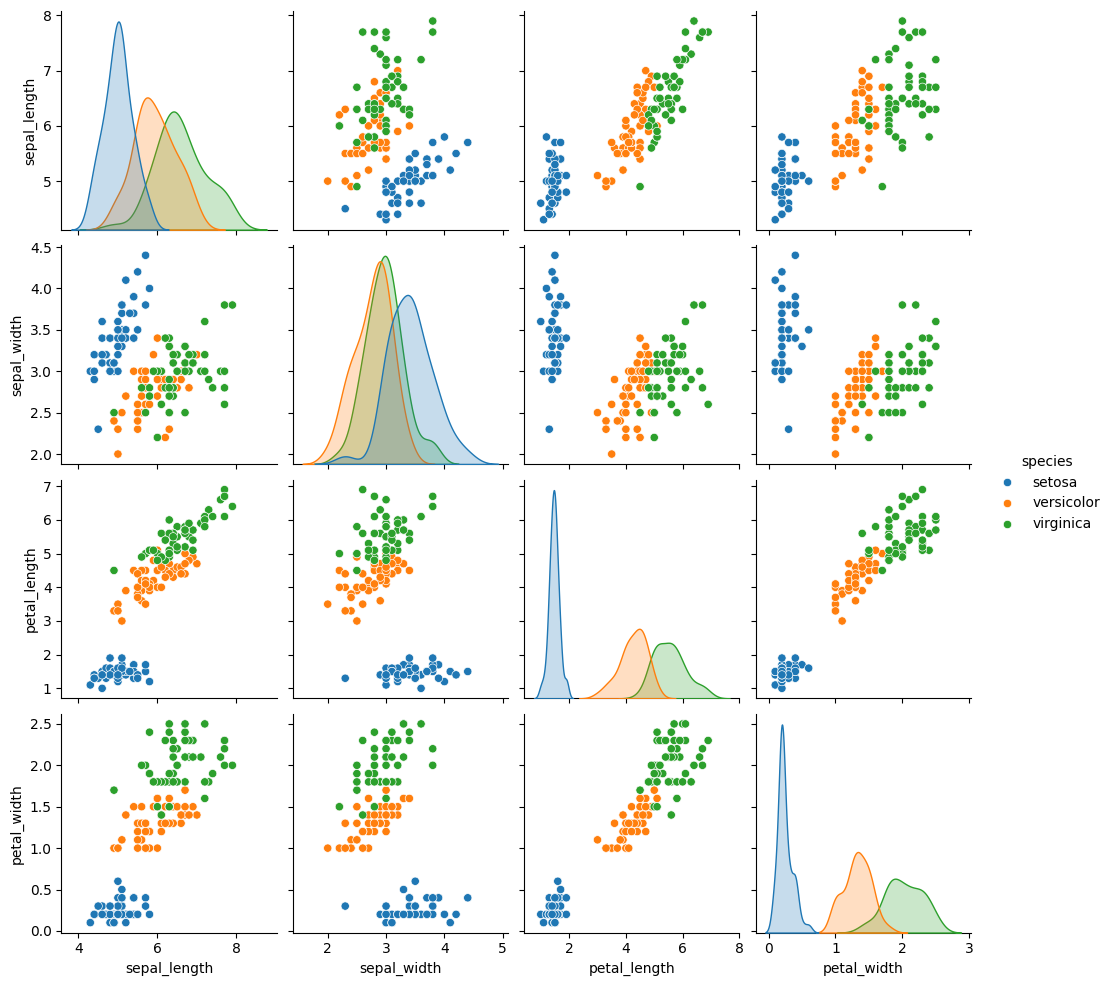

In [125]:
# Pair plot - Matriz de gráficos de dispersão sobre o DF
sns.pairplot(data=df, hue='species')

## Separando o conjunto de dados para treino

Como o objetivo é agrupar as amostras, é necessário remover a coluna **'species'** do conjunto a ser treinado.

In [126]:
X = df.drop(columns=['species'])

## 3 - Definindo o número de clusters

In [127]:
# Espécies distintas das amostras
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

Como pode ser observado no dataset, o conjunto de **espécies distintas é igual a 3**, o qual é, portanto, o número **ideal** de clusters para o algoritmo.

### Método do Cotovelo

Uma outra maneira de se descobrir o número ótimo de clusters é pelo método do cotovelo.

A ideia é rodar o KMeans para diferentes quantidades de clusters, até que a **WCSS** entre os elementos pertencentes ao cluster seja suficientemente próxima de 0.

**WCSS:** serve para medir a similaridade entre sequências de pontos com relação ao centroide.

In [128]:
wcss = []

for n in range(1,10): # A quantidade k de clusters testados varia de 1 a 10
  kmeans = KMeans(n_clusters=n, random_state=51)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

**Análise gráfica:**

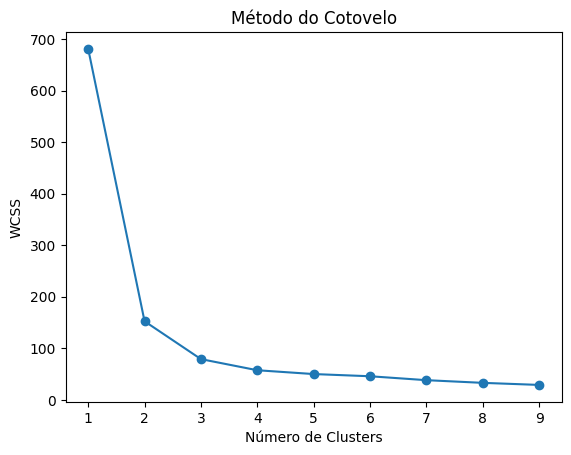

In [129]:
# Exibindo o gráfico de n_clusters x WCSS
plt.plot(range(1,10), wcss, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

Visualmente é possível identificar que o WCSS diminui conforme o número de clusters aumentam, mas a quantidade ótima está situada no "cotovelo" do gráfico, o qual **x = 3.**

### 4 - Execução e visualização sobre os 3 clusters

In [130]:
modelo_kmeans = KMeans(n_clusters=3,random_state=51)
y_kmeans = modelo_kmeans.fit_predict(X)

# Criando um DF para armazenar o ponto no qual se situam os centroides
centroides = pd.DataFrame(modelo_kmeans.cluster_centers_,columns=X.columns)

# Criando uma cópia de X com a coluna dos clusters
X_clusters = X.copy()
X_clusters['clusters'] = y_kmeans

In [131]:
def scatterplot(x,y,data,cent):
  # Representando gráficamente os grupos
  sns.scatterplot(x=x,y=y,data=data,hue='clusters'
                ,palette='tab10')

  # Representando os centroides - X em vermelho no gráfico
  sns.scatterplot(x=x,y=y,data=cent
                  ,c='red',marker='X', s=100)

  plt.title(f'KMeans sobre {x} e {y}')

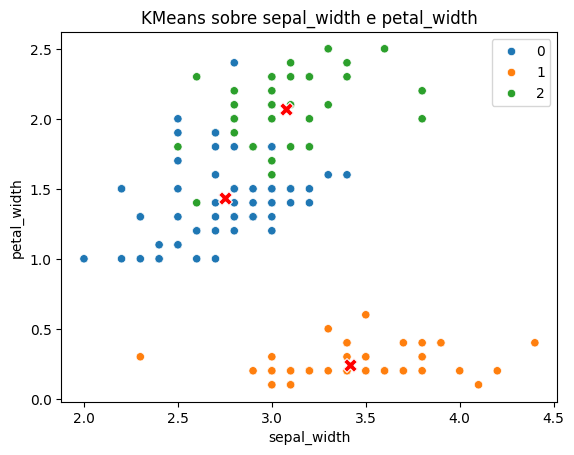

In [132]:
# sepal_width x petal_width
scatterplot('sepal_width', 'petal_width',X_clusters,centroides)

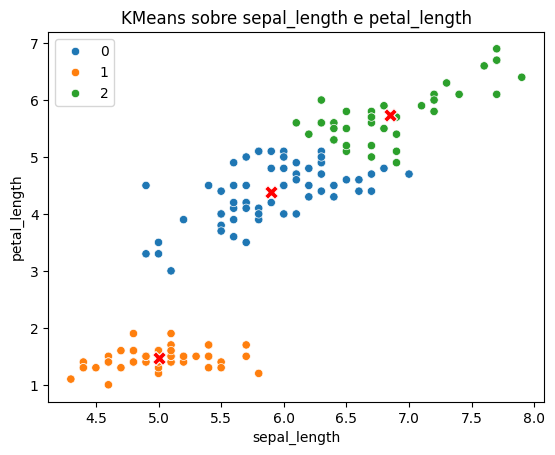

In [133]:
# sepal_length x petal_length
scatterplot('sepal_length', 'petal_length',X_clusters,centroides)

## 5 - Analisando os resultados

Usarei 2 métricas para avaliar o desempenho do modelo:


1.   **Silhouette Score:** analisa a qualidade de separação que os clusters alcançaram, comparando a semelhança de um cluster com outro.

### **5.1 - Silhouette Score**

Varia de -1 a 1, com quanto mais próximo de 1 mais conciso são os clusters, e quanto mais próximo de -1 os clusters são menos bem construídos.

In [134]:
score = silhouette_score(X,y_kmeans)
print(f'Silhouette Score: {score}')

Silhouette Score: 0.5525919445499757


Aqui eu utilizo o DF **X**, pois ele está sem a coluna que possui o resultado dos clusters, o que influenciaria positivamente no score.